In [ ]:
import pandas as pd
import numpy as np
!pip install xgboost

In [ ]:
df = pd.read_csv("Heatwaves.csv")

/tmp/ipykernel_5858/2461805891.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Heatwaves.csv")


In [ ]:
print(df.shape)
print(df.head())
print(df.info())

(77185, 8)
     CITY  YEAR DOY   RH2M  WS2M T2M_MAX T2M_MIN ALLSKY_SFC_SW_DWN
0  kanpur  2000   1  28.28  1.09   24.68     7.4              7.78
1  kanpur  2000   2  27.19  0.77   24.36    9.17              8.35
2  kanpur  2000   3  26.98  1.03   24.07    7.09              8.41
3  kanpur  2000   4   27.3  1.39   24.66    5.61              7.91
4  kanpur  2000   5  24.89  1.43   24.54    8.58              5.47
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77185 entries, 0 to 77184
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CITY               77185 non-null  object
 1   YEAR               77185 non-null  object
 2   DOY                77185 non-null  object
 3   RH2M               77185 non-null  object
 4   WS2M               77185 non-null  object
 5   T2M_MAX            77185 non-null  object
 6   T2M_MIN            77185 non-null  object
 7   ALLSKY_SFC_SW_DWN  77185 non-null  object
dtypes: o

In [ ]:
print(df.isnull().sum())

CITY                 0
YEAR                 0
DOY                  0
RH2M                 0
WS2M                 0
T2M_MAX              0
T2M_MIN              0
ALLSKY_SFC_SW_DWN    0
dtype: int64


In [ ]:
df['YEAR_numeric'] = pd.to_numeric(df['YEAR'], errors='coerce')
df['DOY_numeric'] = pd.to_numeric(df['DOY'], errors='coerce')

df.dropna(subset=['YEAR_numeric', 'DOY_numeric'], inplace=True)

df['DATE'] = pd.to_datetime(
    df['YEAR_numeric'].astype(int).astype(str) +
    df['DOY_numeric'].astype(int).astype(str).str.zfill(3),
    format='%Y%j'
)

df.drop(columns=['YEAR_numeric', 'DOY_numeric'], inplace=True)

In [ ]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 77184 entries, 0 to 77184
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CITY               77184 non-null  object        
 1   YEAR               77184 non-null  object        
 2   DOY                77184 non-null  object        
 3   RH2M               77184 non-null  object        
 4   WS2M               77184 non-null  object        
 5   T2M_MAX            77184 non-null  object        
 6   T2M_MIN            77184 non-null  object        
 7   ALLSKY_SFC_SW_DWN  77184 non-null  object        
 8   DATE               77184 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(8)
memory usage: 5.9+ MB
None
     CITY  YEAR DOY   RH2M  WS2M T2M_MAX T2M_MIN ALLSKY_SFC_SW_DWN       DATE
0  kanpur  2000   1  28.28  1.09   24.68     7.4              7.78 2000-01-01
1  kanpur  2000   2  27.19  0.77   24.36    9.17              8.35 2000-

Convert Weather Columns to Numeric

In [ ]:
weather_cols = [
    'RH2M',
    'WS2M',
    'T2M_MAX',
    'T2M_MIN',
    'ALLSKY_SFC_SW_DWN'
]

for col in weather_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Create Heatwave Target

In [ ]:
df['HEATWAVE'] = (
    df['T2M_MAX'] >= 40
).astype(int)

EDA

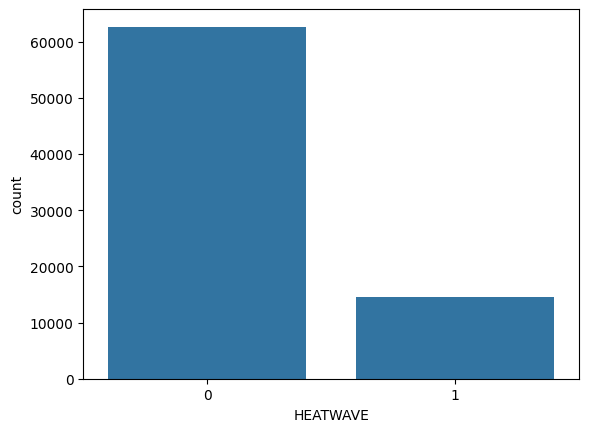

In [ ]:
#Heatwave distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='HEATWAVE',
    data=df
)

plt.show()

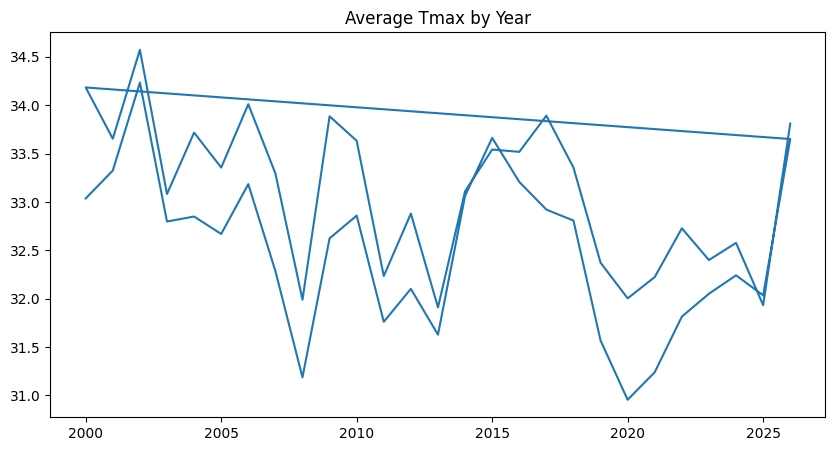

In [ ]:
#Temperature Trend
annual_temp = (
    df.groupby('YEAR')['T2M_MAX']
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(annual_temp)

plt.title(
    'Average Tmax by Year'
)

plt.show()

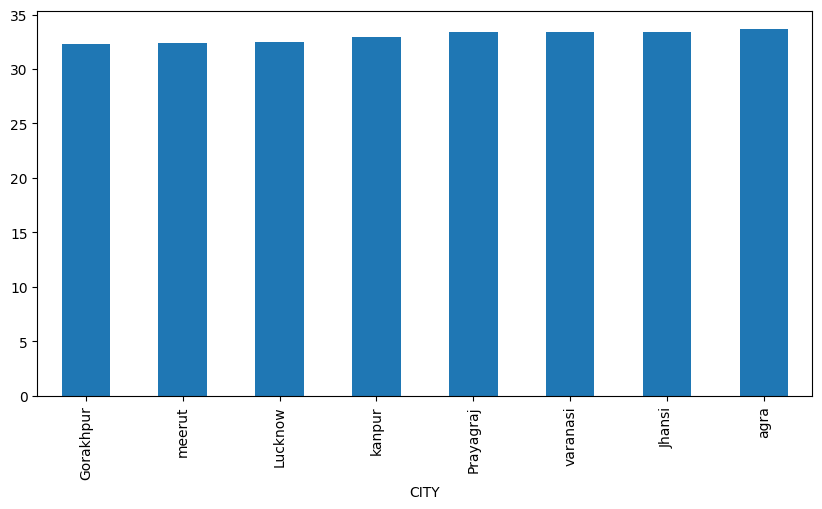

In [ ]:
#City Comparision
city_avg = (
    df.groupby('CITY')['T2M_MAX']
    .mean()
    .sort_values()
)

city_avg.plot(
    kind='bar',
    figsize=(10,5)
)

plt.show()

Sort Dataset

In [ ]:
df = df.sort_values(
    ['CITY','DATE']
)

Create Lag Features

In [ ]:
# Today's heatwave
df['HEATWAVE'] = (
    df['T2M_MAX'] >= 40
).astype(int)

In [ ]:
# Tomorrow's heatwave
df['HEATWAVE_TOMORROW'] = (
    df.groupby('CITY')['HEATWAVE']
      .shift(-1)
)

In [ ]:
#Remove last record
df.dropna(
    subset=['HEATWAVE_TOMORROW'],
    inplace=True
)

In [ ]:
#Lag1
df['TMAX_LAG1'] = (
    df.groupby('CITY')['T2M_MAX']
    .shift(1)
)

In [ ]:
#Lag3
df['TMAX_LAG3'] = (
    df.groupby('CITY')['T2M_MAX']
    .shift(3)
)

In [ ]:
#Lag7
df['TMAX_LAG7'] = (
    df.groupby('CITY')['T2M_MAX']
    .shift(7)
)

In [ ]:
#Lag14
df['TMAX_LAG14'] = (
    df.groupby('CITY')['T2M_MAX']
    .shift(14)
)

Rolling Features

In [ ]:
# 7 day mean
df['TMAX_7D_MEAN'] = (
    df.groupby('CITY')['T2M_MAX']
      .transform(
          lambda x:
          x.rolling(7).mean()
      )
)

In [ ]:
# 14 day mean
df['TMAX_14D_MEAN'] = (
    df.groupby('CITY')['T2M_MAX']
      .transform(
          lambda x:
          x.rolling(14).mean()
      )
)

In [ ]:
# 30 day mean
df['TMAX_30D_MEAN'] = (
    df.groupby('CITY')['T2M_MAX']
      .transform(
          lambda x:
          x.rolling(30).mean()
      )
)

Seasonal Features

In [ ]:
df['MONTH'] = df['DATE'].dt.month

df['DAYOFYEAR'] = (
    df['DATE']
      .dt.dayofyear
)

Cyclic Encoding

In [ ]:
import numpy as np

df['MONTH_SIN'] = np.sin(
    2*np.pi*df['MONTH']/12
)

df['MONTH_COS'] = np.cos(
    2*np.pi*df['MONTH']/12
)

Remove Lag NaNs

In [ ]:
df = df.dropna()

Encode City

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['CITY_ENCODED'] = (
    encoder.fit_transform(
        df['CITY']
    )
)

Select Features

In [ ]:
features = [
'RH2M','WS2M','ALLSKY_SFC_SW_DWN',
'RH_LAG1','WS_LAG1','SOLAR_LAG1',
'TMAX_LAG1','TMAX_LAG3','TMAX_LAG7','TMAX_LAG14',
'TMAX_7D_MEAN','TMAX_14D_MEAN','TMAX_30D_MEAN',
'MONTH_SIN','MONTH_COS','CITY_ENCODED'
]

train=df[df['YEAR']<2024]
test=df[df['YEAR']>=2024]
X_train=train[features]
X_test=test[features]
y_train=train['HEATWAVE_TOMORROW']
y_test=test['HEATWAVE_TOMORROW']

Time-Based Train/Test Split

In [ ]:
train = df[
    df['YEAR'].astype(int) < 2024
]

test = df[
    df['YEAR'].astype(int) >= 2024
]

Prepare Data

In [ ]:
X_train = train[features]
X_test = test[features]

# Leakage-free target
y_train = train['HEATWAVE_TOMORROW']
y_test = test['HEATWAVE_TOMORROW']

Check Class Balance

In [ ]:
print(
    y_train.value_counts()
)

HEATWAVE_TOMORROW
0.0    56705
1.0    13191
Name: count, dtype: int64


Train XGBoost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

Predictions

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

Evaluation

Detailed Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97      5731
         1.0       0.85      0.84      0.85      1317

    accuracy                           0.94      7048
   macro avg       0.91      0.91      0.91      7048
weighted avg       0.94      0.94      0.94      7048



Confusion Matrix

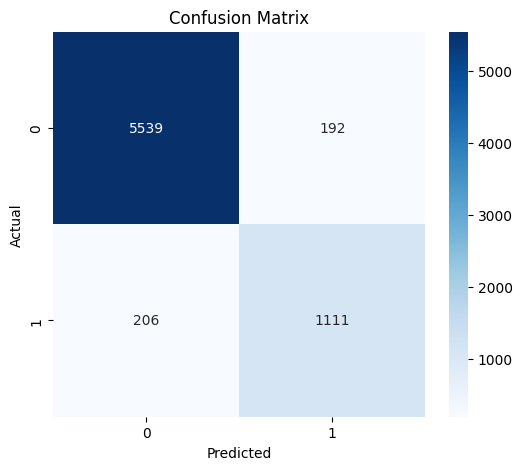

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Feature Importance

<Figure size 1000x800 with 0 Axes>

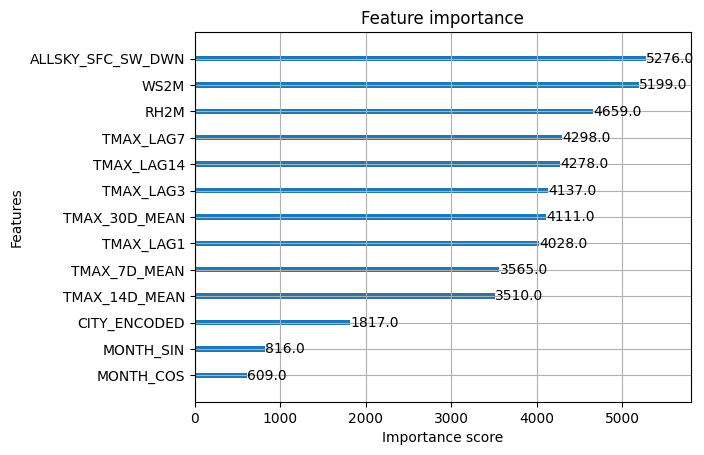

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    model,
    max_num_features=15
)

plt.show()

Better Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
3           TMAX_LAG1    0.544703
7        TMAX_7D_MEAN    0.176226
0                RH2M    0.054416
8       TMAX_14D_MEAN    0.033762
2   ALLSKY_SFC_SW_DWN    0.031588
11          MONTH_COS    0.029586
10          MONTH_SIN    0.025997
9       TMAX_30D_MEAN    0.025236
6          TMAX_LAG14    0.016840
1                WS2M    0.016292
4           TMAX_LAG3    0.016014
5           TMAX_LAG7    0.015830
12       CITY_ENCODED    0.013511


Plot Feature Importance

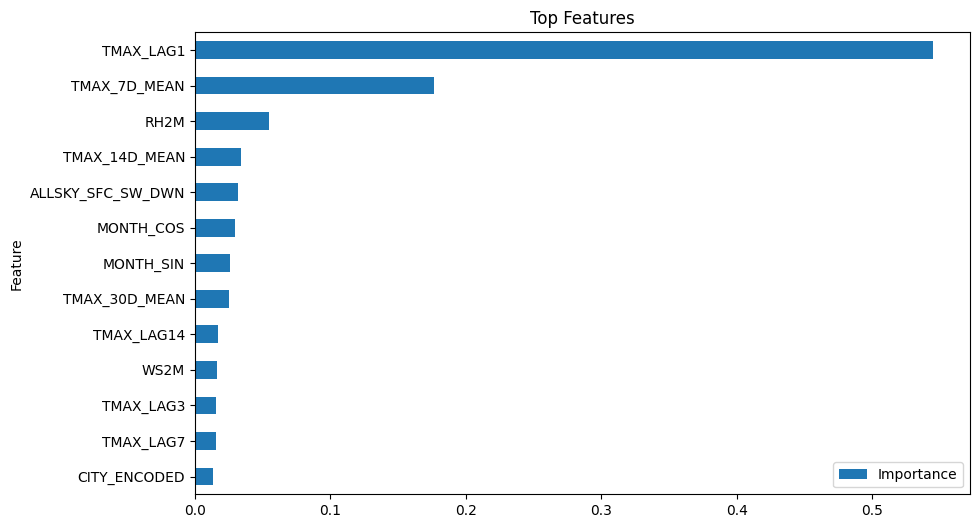

In [ ]:
importance.head(15).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,6)
)

plt.gca().invert_yaxis()

plt.title(
    "Top Features"
)

plt.show()

ROC Curve

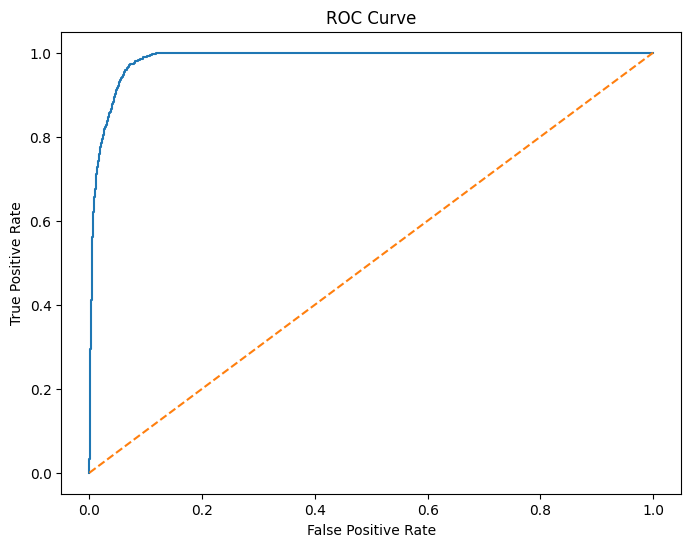

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

Save Model

In [ ]:
import joblib

joblib.dump(
    model,
    'heatwave_xgb.pkl'
)

['heatwave_xgb.pkl']

Save Label Encoder

In [ ]:
joblib.dump(
    encoder,
    'city_encoder.pkl'
)

['city_encoder.pkl']

SHAP Explainability

In [ ]:
!pip install shap
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

SHAP Summary Plot

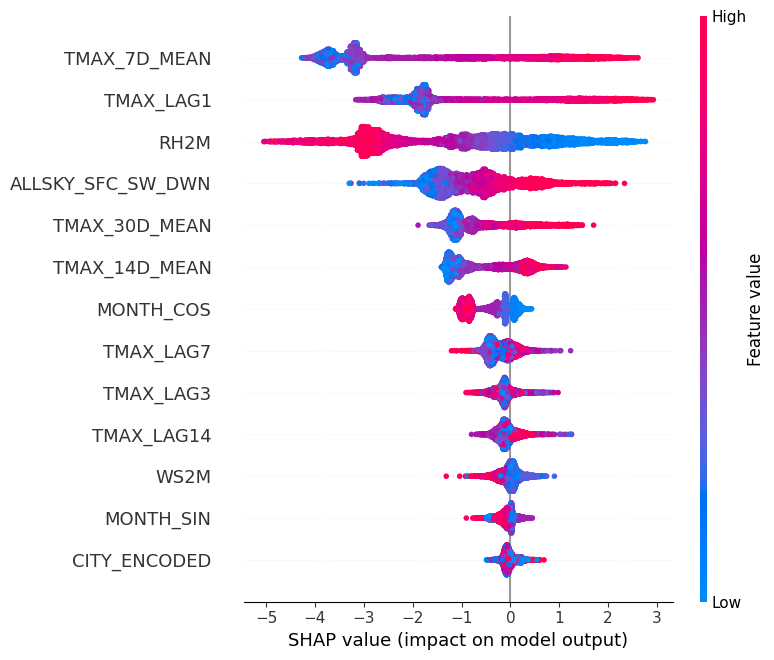

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

SHAP Bar Plot

```
# This is formatted as code
```



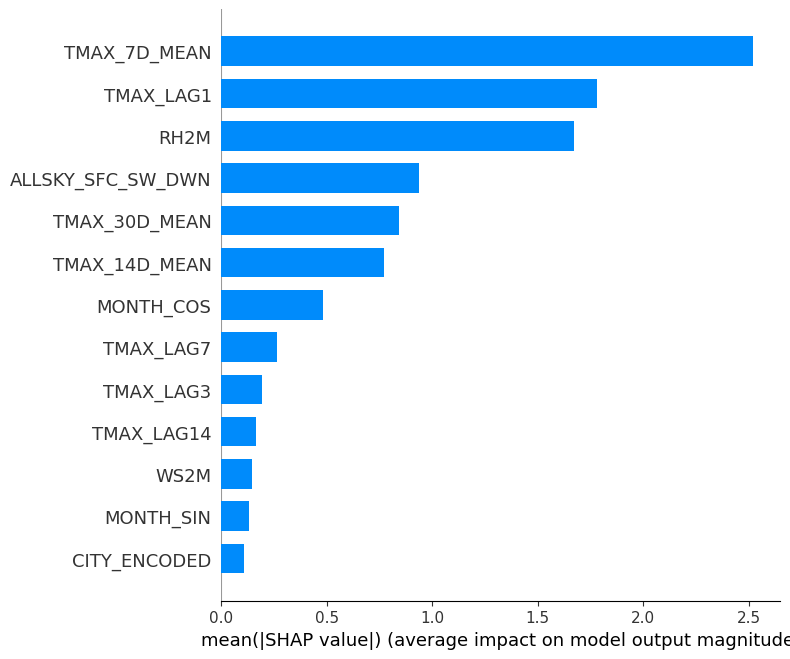

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

Model Performance Summary

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Value":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ]
})

print(results)

      Metric     Value
0   Accuracy  0.943530
1  Precision  0.852648
2     Recall  0.843584
3         F1  0.848092
4    ROC-AUC  0.985748


Heatwave Trend Analysis

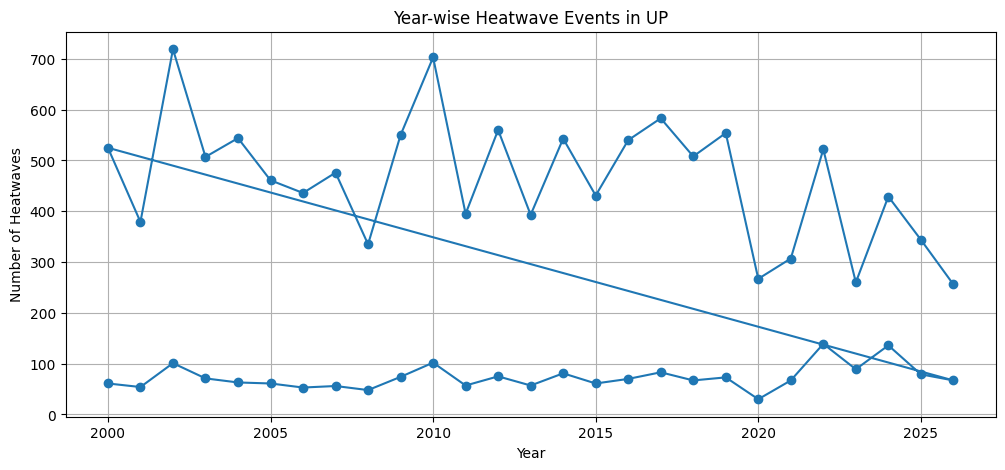

In [ ]:
#year-wise heatwave
heatwave_yearly = (
    df.groupby('YEAR')['HEATWAVE']
      .sum()
)

plt.figure(figsize=(12,5))
plt.plot(
    heatwave_yearly.index,
    heatwave_yearly.values,
    marker='o'
)

plt.title("Year-wise Heatwave Events in UP")
plt.xlabel("Year")
plt.ylabel("Number of Heatwaves")

plt.grid()

plt.show()

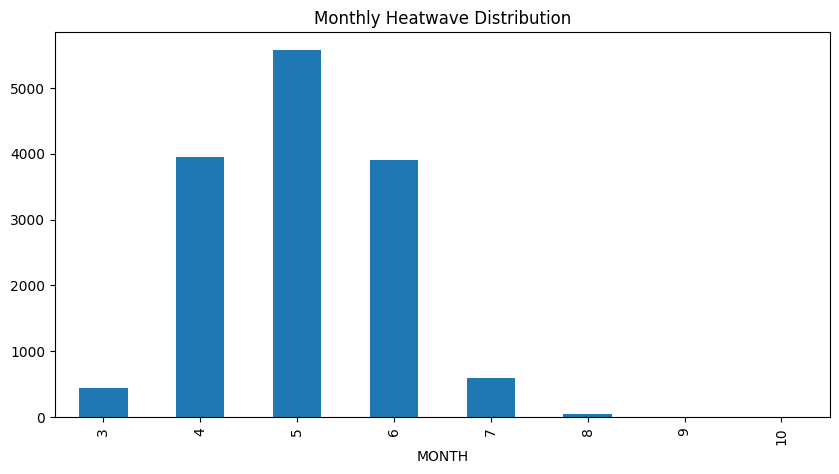

In [ ]:
#Monthly heatwave distribution
monthly_hw = (
    df[df['HEATWAVE']==1]
    .groupby('MONTH')
    .size()
)

plt.figure(figsize=(10,5))

monthly_hw.plot(
    kind='bar'
)

plt.title(
    "Monthly Heatwave Distribution"
)

plt.show()

City-wise Heatwave Analysis

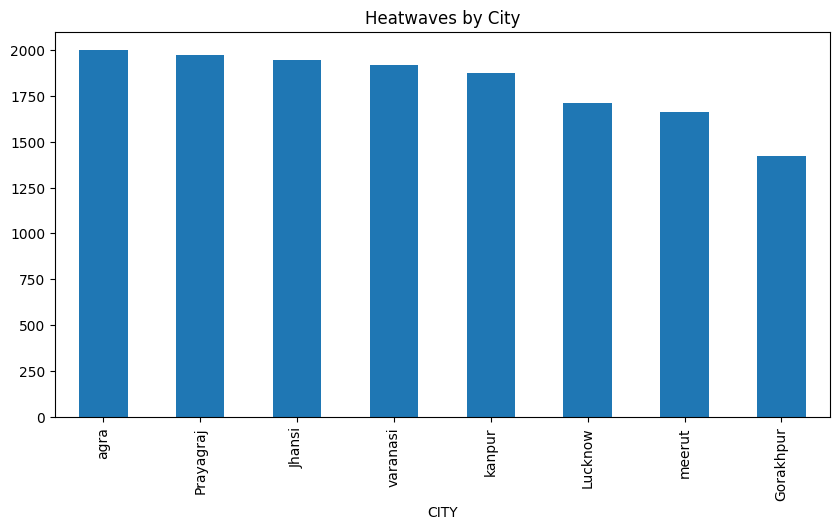

In [ ]:
city_heatwave = (
    df.groupby('CITY')['HEATWAVE']
      .sum()
      .sort_values(
          ascending=False
      )
)

plt.figure(figsize=(10,5))

city_heatwave.plot(
    kind='bar'
)

plt.title(
    "Heatwaves by City"
)

plt.show()

SHAP Explainability

In [ ]:
!pip install shap
import shap

explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_test
)

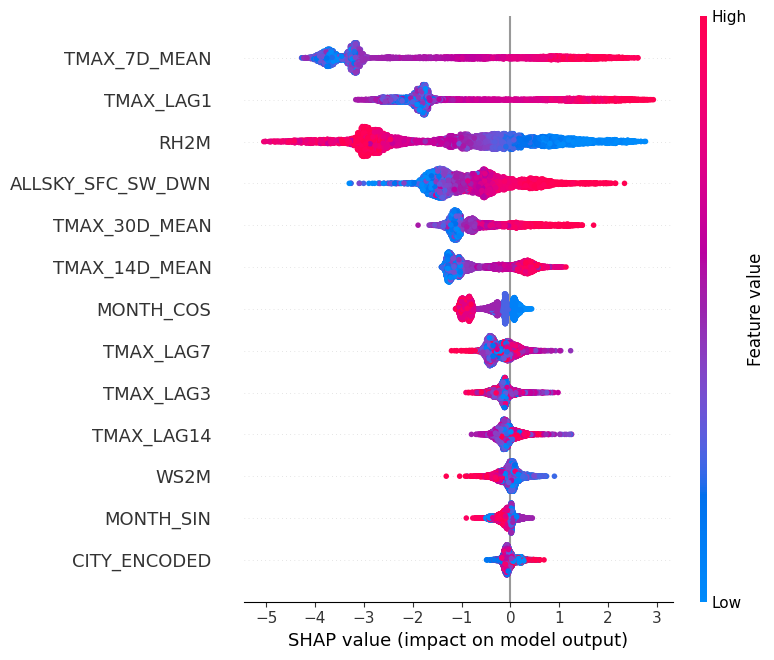

In [ ]:
#Global Feature Importance
shap.summary_plot(
    shap_values,
    X_test
)

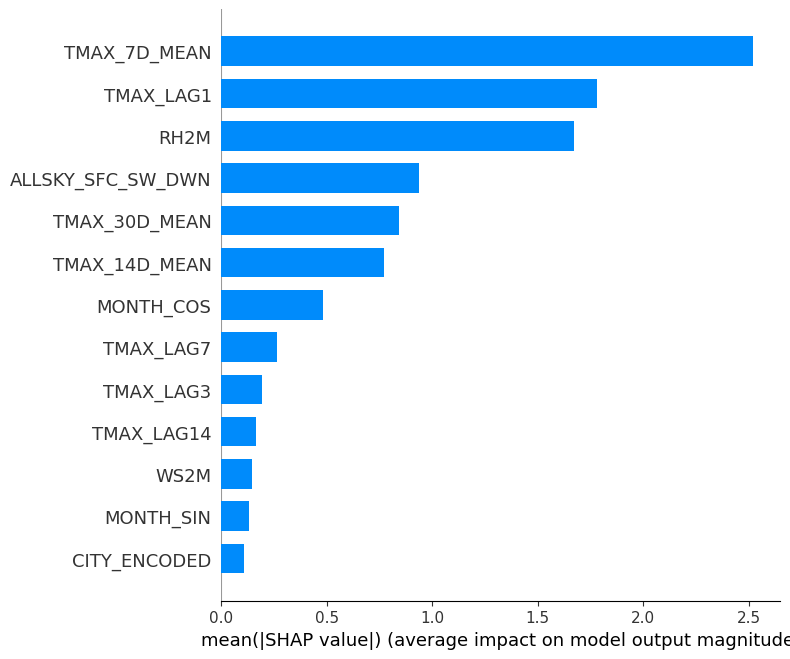

In [ ]:
#Bar plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

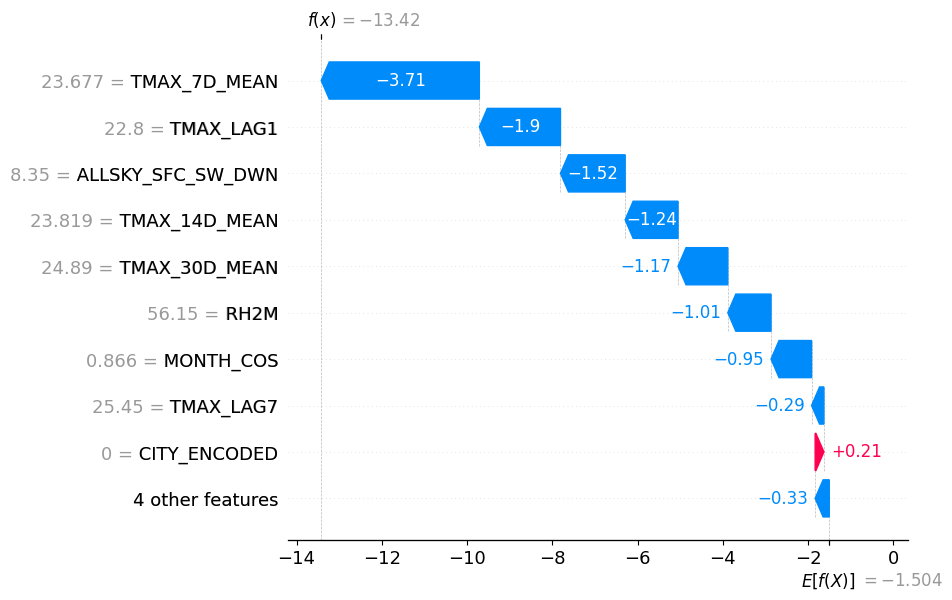

In [ ]:
#Single Prediction Explanation
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = (
    importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print(
    importance
)

              Feature  Importance
3           TMAX_LAG1    0.544703
7        TMAX_7D_MEAN    0.176226
0                RH2M    0.054416
8       TMAX_14D_MEAN    0.033762
2   ALLSKY_SFC_SW_DWN    0.031588
11          MONTH_COS    0.029586
10          MONTH_SIN    0.025997
9       TMAX_30D_MEAN    0.025236
6          TMAX_LAG14    0.016840
1                WS2M    0.016292
4           TMAX_LAG3    0.016014
5           TMAX_LAG7    0.015830
12       CITY_ENCODED    0.013511


Final Model

In [ ]:
import joblib

joblib.dump(
    model,
    "heatwave_final.pkl"
)

joblib.dump(
    encoder,
    "city_encoder.pkl"
)

['city_encoder.pkl']

Create Prediction Function

In [ ]:
def predict_heatwave(
        input_data
):

    prob = (
        model.predict_proba(
            input_data
        )[0][1]
    )

    pred = (
        model.predict(
            input_data
        )[0]
    )

    return pred, prob